<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/01_eda_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:02<00:00, 166MB/s]



In [2]:
import os
for root, dirs, files in os.walk('data'):
    level = root.replace('data', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files)} fajlova)')

data/ (2 fajlova)
  tom_and_jerry/ (0 fajlova)
    tom_and_jerry/ (0 fajlova)
      tom/ (1930 fajlova)
      jerry/ (1240 fajlova)
      tom_jerry_1/ (780 fajlova)
      tom_jerry_0/ (1528 fajlova)


In [3]:
import os
for f in os.listdir('data'):
    if os.path.isfile(os.path.join('data', f)):
        print(f)

challenges.csv
ground_truth.csv


In [4]:
import pandas as pd

gt = pd.read_csv('data/ground_truth.csv')
print("ground_truth.csv:", gt.shape)
print(gt.head())
print()

ch = pd.read_csv('data/challenges.csv')
print("challenges.csv:", ch.shape)
print(ch.head())


ground_truth.csv: (5478, 3)
     filename  tom  jerry
0  frame0.jpg    0      0
1  frame1.jpg    0      0
2  frame2.jpg    0      0
3  frame3.jpg    0      0
4  frame4.jpg    0      0

challenges.csv: (32, 2)
  folder     image_name
0  jerry   frame360.jpg
1  jerry  frame1794.jpg
2  jerry  frame1795.jpg
3  jerry  frame2231.jpg
4  jerry  frame2234.jpg


In [5]:
import pandas as pd
import re

gt = pd.read_csv('data/ground_truth.csv')

# klasa iz tom/jerry kolona
def get_class(row):
    if row['tom'] == 1 and row['jerry'] == 1:
        return 'both'
    elif row['tom'] == 1:
        return 'tom'
    elif row['jerry'] == 1:
        return 'jerry'
    else:
        return 'neither'

gt['class'] = gt.apply(get_class, axis=1)
print(gt['class'].value_counts())
print(gt['class'].value_counts(normalize=True).round(3))

# izvuci broj frejma iz imena fajla, radi grupisanja za split
gt['frame_num'] = gt['filename'].str.extract(r'(\d+)').astype(int)
gt = gt.sort_values('frame_num').reset_index(drop=True)

# grupiši svakih 50 uzastopnih frejmova u jedan "blok" - ceo blok ide ili u train ili u test,
# tako susedni (skoro identični) frejmovi nikad ne budu razdvojeni preko granice
gt['block'] = gt['frame_num'] // 50

print(f"\nBroj blokova: {gt['block'].nunique()}")
print(f"Opseg frame_num: {gt['frame_num'].min()} - {gt['frame_num'].max()}")

class
tom        1930
neither    1528
jerry      1240
both        780
Name: count, dtype: int64
class
tom        0.352
neither    0.279
jerry      0.226
both       0.142
Name: proportion, dtype: float64

Broj blokova: 110
Opseg frame_num: 0 - 5477


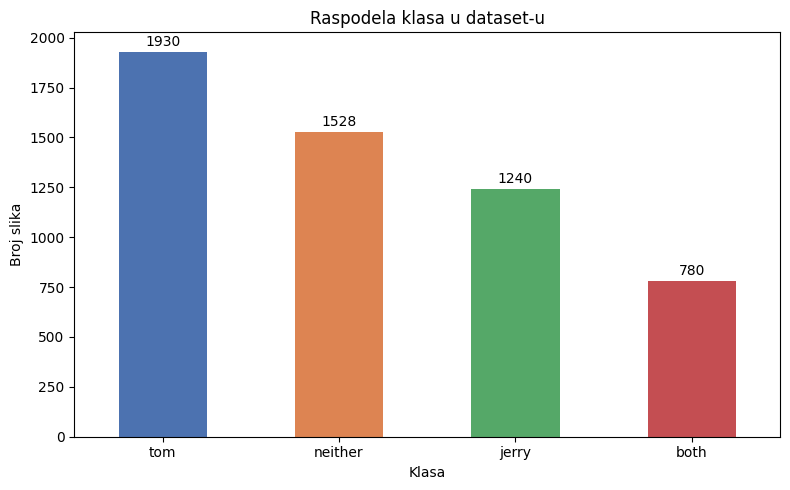

In [6]:
import matplotlib.pyplot as plt

class_counts = gt['class'].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Raspodela klasa u dataset-u')
plt.xlabel('Klasa')
plt.ylabel('Broj slika')
plt.xticks(rotation=0)
for i, v in enumerate(class_counts):
    plt.text(i, v + 30, str(v), ha='center')
plt.tight_layout()
plt.show()

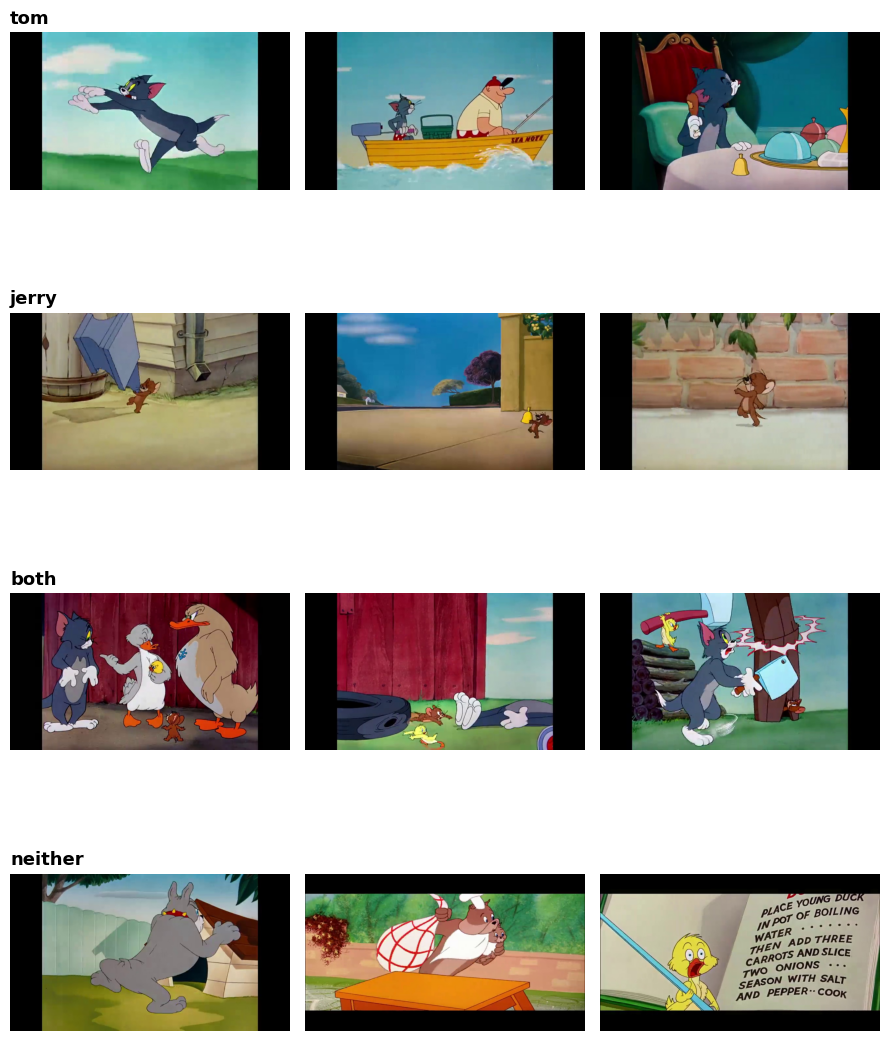

In [7]:
import cv2

folder_map = {'tom': 'tom', 'jerry': 'jerry', 'both': 'tom_jerry_1', 'neither': 'tom_jerry_0'}
base_dir = '/content/data/tom_and_jerry/tom_and_jerry/'
classes = ['tom', 'jerry', 'both', 'neither']

fig, axes = plt.subplots(4, 3, figsize=(9, 12))

for row_i, cls in enumerate(classes):
    samples = gt[gt['class'] == cls].sample(3, random_state=42)
    for col_i, (_, sample_row) in enumerate(samples.iterrows()):
        path = base_dir + folder_map[cls] + '/' + sample_row['filename']
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].axis('off')
    axes[row_i, 0].set_title(cls, fontsize=13, loc='left', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# klasa koja preovlađuje u svakom bloku - koristimo je za stratifikaciju
block_class = gt.groupby('block')['class'].agg(lambda x: x.value_counts().idxmax())
blocks = block_class.index.values
classes_per_block = block_class.values

# prvo izdvoji test (15% blokova)
train_val_blocks, test_blocks = train_test_split(
    blocks, test_size=0.15, stratify=classes_per_block, random_state=42
)

# od ostatka izdvoji validaciju (tako da na kraju bude ~70/15/15 od ukupnog)
train_val_classes = block_class.loc[train_val_blocks].values
train_blocks, val_blocks = train_test_split(
    train_val_blocks, test_size=0.1765, stratify=train_val_classes, random_state=42
)

train_set, val_set, test_set = set(train_blocks), set(val_blocks), set(test_blocks)

def assign_split(block):
    if block in train_set:
        return 'train'
    elif block in val_set:
        return 'val'
    else:
        return 'test'

gt['split'] = gt['block'].apply(assign_split)

print(gt['split'].value_counts())
print()
print(gt.groupby('split')['class'].value_counts(normalize=True).round(3))

split
train    3778
val       850
test      850
Name: count, dtype: int64

split  class  
test   tom        0.345
       neither    0.271
       jerry      0.231
       both       0.154
train  tom        0.350
       neither    0.286
       jerry      0.223
       both       0.141
val    tom        0.369
       neither    0.256
       jerry      0.239
       both       0.135
Name: proportion, dtype: float64


In [9]:
!pwd

/content


In [10]:
!ls


data  sample_data  tom-and-jerry-image-classification.zip


In [11]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"
!pwd

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 23 (delta 8), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 29.07 MiB | 30.88 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/Tom-and-Jerry-Character-Classification
/content/Tom-and-Jerry-Character-Classification


In [12]:
!pwd


/content/Tom-and-Jerry-Character-Classification


In [13]:
gt[['filename', 'tom', 'jerry', 'class', 'split']].to_csv('data_split.csv', index=False)

!git add data_split.csv
!git commit -m "add train/val/test split (70/15/15, block-based, stratified)"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [14]:
with open('.gitignore', 'w') as f:
    f.write("data/\n*.zip\n")

!git add .gitignore
!git commit -m "add gitignore"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
